## RPDA8412 - PCOS Classification - Research Pipeline

| **Component** | **Details** |
|---------------|-------------|
| **Researcher** | ST10252746 \| Theshara Narain |
| **Module** | RPDA8412 Semester 2 |
| **Study Title** | A Comparative Evaluation of Traditional and Neural Network Models for Polycystic Ovary Syndrome (PCOS) Classification: Performance, Interpretability, and Clinical Implications |
| **Ethical Clearance** | EMCSREC/EMKNDN/025/2026 (approved 13 July 2026) |
| **Random Seed** | `RANDOM_STATE = 42` applied to *all* stochastic operations |


### Datasets

| **Dataset** | **Source** | **Year** | **License** | **Purpose** |
|-------------|------------|----------|-------------|-------------|
| Primary | Soares, L.S. | 2025 | MIT | Training / Test |
| External Validation | Dalvi, S. | 2024 | CC0 1.0 | External validation |
| SHAP Interpretability | Moheddine, A. | 2022 | Attribution maintained | Supplementary interpretability analysis |


### Pipeline Stages

| **Stage** | **Description** |
|-----------|-----------------|
| **1. Data Loading** | Import all three datasets with appropriate handling |
| **2. Preprocessing** | Handling missing values, encoding, scaling, feature selection |
| **3. Train/Test Split** | Stratified split using `RANDOM_STATE = 42` |
| **4. Model Training (Traditional)** | Logistic Regression, Random Forest, SVM, etc. |
| **5. Model Training (Neural)** | MLP, CNN, or custom architectures |
| **6. Hyperparameter Tuning** | Grid/Random Search with `RANDOM_STATE = 42` |
| **7. Performance Evaluation** | Accuracy, Precision, Recall, F1, AUC-ROC |
| **8. External Validation** | Evaluate best models on Dalvi (2024) dataset |
| **9. Interpretability** | SHAP analysis on Moheddine (2022) dataset |
| **10. Comparative Analysis** | Traditional vs Neural - performance, interpretability, clinical utility |


### Reproducibility Note
> All decisions are recorded in markdown cells above the relevant code blocks.  
> `RANDOM_STATE = 42` is applied globally to ensure deterministic outputs.

*This notebook documents the full machine learning pipeline from data loading through 
to interpretability analysis. All decisions are recorded in markdown cells above the 
relevant code blocks.*

---

## Section 1: Library Imports

All libraries are imported here to make dependencies explicit and reproducible. 
Versions are printed for documentation purposes.

In [1]:
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "imbalanced-learn", "shap", "joblib"
])

0

In [2]:
# ============================================================
# SECTION 1: LIBRARY IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import shap
import platform
import sys

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set global random state for reproducibility
RANDOM_STATE = 42

# Set consistent plot styling
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Print library versions for reproducibility documentation
print("=== Environment Information ===")
print(f"Python version   : {sys.version}")
print(f"Platform         : {platform.system()} {platform.release()}")
print(f"pandas version   : {pd.__version__}")
print(f"numpy version    : {np.__version__}")
print(f"matplotlib ver   : {matplotlib.__version__}")
print(f"scikit-learn ver : {sklearn.__version__}")
print(f"shap version     : {shap.__version__}")
print(f"RANDOM_STATE     : {RANDOM_STATE}")

c:\Users\NarainT\source\VSC repos\ST10252746_RPDA8412_PCOS_Classification\pcos_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Environment Information ===
Python version   : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Platform         : Windows 10
pandas version   : 3.0.5
numpy version    : 2.4.6
matplotlib ver   : 3.11.1
scikit-learn ver : 1.9.0
shap version     : 0.51.0
RANDOM_STATE     : 42


## Section 2: Data Loading

Three datasets are loaded from the `../data/` directory. File paths are defined 
centrally so that any renaming only requires a change in one location.

The datasets and their roles in this study are:
- **Soares (2025):** Primary training and test data. 3,000 records, 5 predictors, 
  1 target variable. MIT Licence.
- **Dalvi (2024):** External validation only. 1,000 records, identical schema to Soares. 
  CC0 1.0. This dataset will not be used for training or preprocessing fitting.
- **Moheddine (2022):** Supplementary SHAP interpretability analysis. 541 records, 
  44 columns including a richer set of clinical variables. Licence unknown on Kaggle; 
  full attribution maintained throughout.

In [3]:
# ============================================================
# SECTION 2: DATA LOADING
# ============================================================

# Define file paths relative to this notebook's location
SOARES_PATH    = '../data/soares_pcos.csv'
DALVI_PATH     = '../data/dalvi_pcos.csv'
MOHEDDINE_PATH = '../data/moheddine_pcos.csv'

# Load datasets
soares    = pd.read_csv(SOARES_PATH)
dalvi     = pd.read_csv(DALVI_PATH)
moheddine = pd.read_csv(MOHEDDINE_PATH)

print("All three datasets loaded successfully.")
print(f"  Soares    : {soares.shape[0]:,} rows x {soares.shape[1]} columns")
print(f"  Dalvi     : {dalvi.shape[0]:,} rows x {dalvi.shape[1]} columns")
print(f"  Moheddine : {moheddine.shape[0]:,} rows x {moheddine.shape[1]} columns")

All three datasets loaded successfully.
  Soares    : 3,000 rows x 6 columns
  Dalvi     : 1,000 rows x 6 columns
  Moheddine : 541 rows x 44 columns


## Section 3: Data Validation

Before any preprocessing or modelling is performed, each dataset is inspected to 
confirm:
1. Shape (rows and columns match what was described in the proposal)
2. Column names and data types
3. Missing values (count per column)
4. Duplicate rows
5. Class distribution of the target variable

Any issues identified here must be resolved before proceeding to preprocessing. 
All findings are documented for inclusion in the Methodology section of the 
research report.

In [4]:
# ============================================================
# SECTION 3: DATA VALIDATION - UTILITY FUNCTION
# ============================================================

def validate_dataset(name, df, target_col):
    """
    Produces a structured validation summary for a dataset.
    
    Parameters
    ----------
    name       : str  - Dataset label for display
    df         : pd.DataFrame - The dataset to validate
    target_col : str  - Name of the target/outcome column
    """
    print("=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)
    
    # Shape
    print(f"\n[Shape]\n  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
    
    # Column names
    print(f"\n[Columns]\n  {list(df.columns)}")
    
    # Data types
    print(f"\n[Data Types]")
    print(df.dtypes.to_string())
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0]
    if missing_df.empty:
        print(f"\n[Missing Values]\n  None detected.")
    else:
        print(f"\n[Missing Values — columns with missing data]")
        print(missing_df.to_string())
    
    # Duplicates
    dup_count = df.duplicated().sum()
    print(f"\n[Duplicate Rows]\n  {dup_count} duplicate(s) found.")
    
    # Class distribution
    if target_col in df.columns:
        dist = df[target_col].value_counts()
        dist_pct = df[target_col].value_counts(normalize=True).mul(100).round(2)
        class_df = pd.DataFrame({'Count': dist, 'Percentage (%)': dist_pct})
        print(f"\n[Class Distribution — '{target_col}']")
        print(class_df.to_string())
        
        # Flag imbalance
        majority_pct = dist_pct.max()
        if majority_pct >= 70:
            print(f"\n  *** CLASS IMBALANCE DETECTED: majority class = {majority_pct}% ***")
            print(f"  SMOTE will be applied to the training set only after the train-test split.")
    else:
        print(f"\n  [WARNING] Target column '{target_col}' not found in this dataset.")
    
    print("\n")
    
    return missing_df, dup_count

### 3.1 Soares Dataset Validation

In [5]:
# ============================================================
# VALIDATE: SOARES DATASET (primary training/test)
# ============================================================

soares_missing, soares_dups = validate_dataset(
    name='Soares (2025) - Primary Dataset',
    df=soares,
    target_col='PCOS_Diagnosis'
)

DATASET: Soares (2025) - Primary Dataset

[Shape]
  Rows: 3,000  |  Columns: 6

[Columns]
  ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count', 'PCOS_Diagnosis']

[Data Types]
Age                            int64
BMI                          float64
Menstrual_Irregularity         int64
Testosterone_Level(ng/dL)    float64
Antral_Follicle_Count          int64
PCOS_Diagnosis                 int64

[Missing Values]
  None detected.

[Duplicate Rows]
  0 duplicate(s) found.

[Class Distribution — 'PCOS_Diagnosis']
                Count  Percentage (%)
PCOS_Diagnosis                       
0                2400            80.0
1                 600            20.0

  *** CLASS IMBALANCE DETECTED: majority class = 80.0% ***
  SMOTE will be applied to the training set only after the train-test split.




**Soares Dataset - Validation Observations**

The Soares dataset loaded with 3,000 records and six columns, which is consistent
with the dataset description provided in the approved research proposal. All five
predictor variables (Age, BMI, Menstrual Irregularity, Testosterone Level, and
Antral Follicle Count) are numeric, requiring no categorical encoding before
scaling. No missing values or duplicate records were detected, meaning the dataset
can proceed directly to the train-test split without any imputation or deduplication
steps.

The target variable (PCOS_Diagnosis) shows an 80.0% negative class majority,
confirming the approximate class imbalance figure stated in the proposal. This
level of imbalance is sufficient to cause models to favour the negative class if
left unaddressed, which would produce misleadingly high accuracy while performing
poorly on positive-case detection. The Synthetic Minority Oversampling Technique
(SMOTE) will be applied to the training set only, after the stratified split, to
address this imbalance without introducing data leakage into the test set
(Japkowicz and Shah, 2011).

### 3.2 Dalvi Dataset Validation

In [6]:
# ============================================================
# VALIDATE: DALVI DATASET (external validation)
# ============================================================

dalvi_missing, dalvi_dups = validate_dataset(
    name='Dalvi (2024) - External Validation Dataset',
    df=dalvi,
    target_col='PCOS_Diagnosis'
)

DATASET: Dalvi (2024) - External Validation Dataset

[Shape]
  Rows: 1,000  |  Columns: 6

[Columns]
  ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count', 'PCOS_Diagnosis']

[Data Types]
Age                            int64
BMI                          float64
Menstrual_Irregularity         int64
Testosterone_Level(ng/dL)    float64
Antral_Follicle_Count          int64
PCOS_Diagnosis                 int64

[Missing Values]
  None detected.

[Duplicate Rows]
  0 duplicate(s) found.

[Class Distribution — 'PCOS_Diagnosis']
                Count  Percentage (%)
PCOS_Diagnosis                       
0                 801            80.1
1                 199            19.9

  *** CLASS IMBALANCE DETECTED: majority class = 80.1% ***
  SMOTE will be applied to the training set only after the train-test split.




**Dalvi Dataset - Validation Observations**

The Dalvi dataset loaded with 1,000 records and six columns, sharing an identical
schema with the Soares dataset. This schema alignment is a prerequisite for valid
external validation, as it means the MinMaxScaler fitted on the Soares training
data can be applied directly to the Dalvi dataset without any feature engineering
or column remapping.

The class distribution in Dalvi (80.1% negative, 19.9% positive) is near-identical
to Soares, which supports the use of Dalvi as a valid external validation set. A
large distributional difference between the two datasets would have raised questions
about whether they were drawn from comparable populations. No missing values or
duplicates were found. This dataset will not be used for training or for fitting any
preprocessing parameters - it is reserved exclusively for external validation after
all models have been trained on Soares (Bharati, Podder and Mondal, 2020).

### 3.3 Moheddine Dataset Validation

The Moheddine dataset contains 44 columns, including several with string (object) 
data types. These will be identified here and handled before SHAP interpretability 
analysis in a later stage. This dataset is not used for model training.

In [7]:
# ============================================================
# VALIDATE: MOHEDDINE DATASET (supplementary SHAP interpretability)
# ============================================================

moheddine_missing, moheddine_dups = validate_dataset(
    name='Moheddine (2022) - Supplementary SHAP Dataset',
    df=moheddine,
    target_col='PCOS (Y/N)'
)

# Additionally identify columns with non-numeric (object) dtypes
# These require encoding before SHAP analysis
object_cols = moheddine.select_dtypes(include='object').columns.tolist()
print(f"[String/Object Columns in Moheddine - require encoding before SHAP]")
if object_cols:
    for col in object_cols:
        print(f"  - '{col}'  |  Sample values: {moheddine[col].dropna().unique()[:5].tolist()}")
else:
    print("  None detected - all columns are numeric.")

DATASET: Moheddine (2022) - Supplementary SHAP Dataset

[Shape]
  Rows: 541  |  Columns: 44

[Columns]
  ['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']

[Data Types]
Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int6

**Moheddine Dataset - Validation Observations**

The Moheddine dataset loaded with 541 records and 44 columns, making it
substantially richer in clinical features than the Soares or Dalvi datasets. The
44 variables include hormonal markers (FSH, LH, AMH, TSH), physical measurements
(BMI, waist-hip ratio, blood pressure), lifestyle indicators (fast food consumption,
exercise), and ultrasound findings (follicle counts bilaterally). This breadth makes
the dataset well-suited to the extended SHAP interpretability analysis planned for
Stage 9 of the pipeline, where richer feature attribution can be examined across a
wider clinical variable set (Lundberg and Lee, 2017).

Two columns were identified as object (string) data type: `II    beta-HCG(mIU/mL)`
and `AMH(ng/mL)`. Inspection of sample values confirms that both columns contain
numeric data stored as strings, most likely due to formatting inconsistencies in the
original source file. These columns will be converted to float64 before SHAP
analysis using `pd.to_numeric()` with error coercion to handle any non-numeric
entries safely.

Two missing values were also detected: one in `Marraige Status (Yrs)` and one in
`Fast food (Y/N)`. Given that only one value is missing per column out of 541
records (0.18% each), median imputation will be applied for the numeric column and
mode imputation for the binary column. These decisions will be documented in the
Methodology section of the research report. This dataset is not used for model
training, so these issues do not affect the primary pipeline.

The target variable (PCOS (Y/N)) shows a 67.3% / 32.7% split, which is less
imbalanced than Soares or Dalvi. This difference is expected, as Moheddine is
derived from a clinical dataset rather than a synthetically generated one, and the
PCOS prevalence in clinical settings tends to be higher than population-level
estimates (Teede et al., 2018).

## Section 4: Class Distribution Visualisation

Class imbalance is visualised for all three datasets. The proposal noted an 
approximate 80% negative class majority in the Soares dataset. This is confirmed 
or corrected here. Visualisations are saved to `../outputs/figures/` for inclusion 
in the research report.

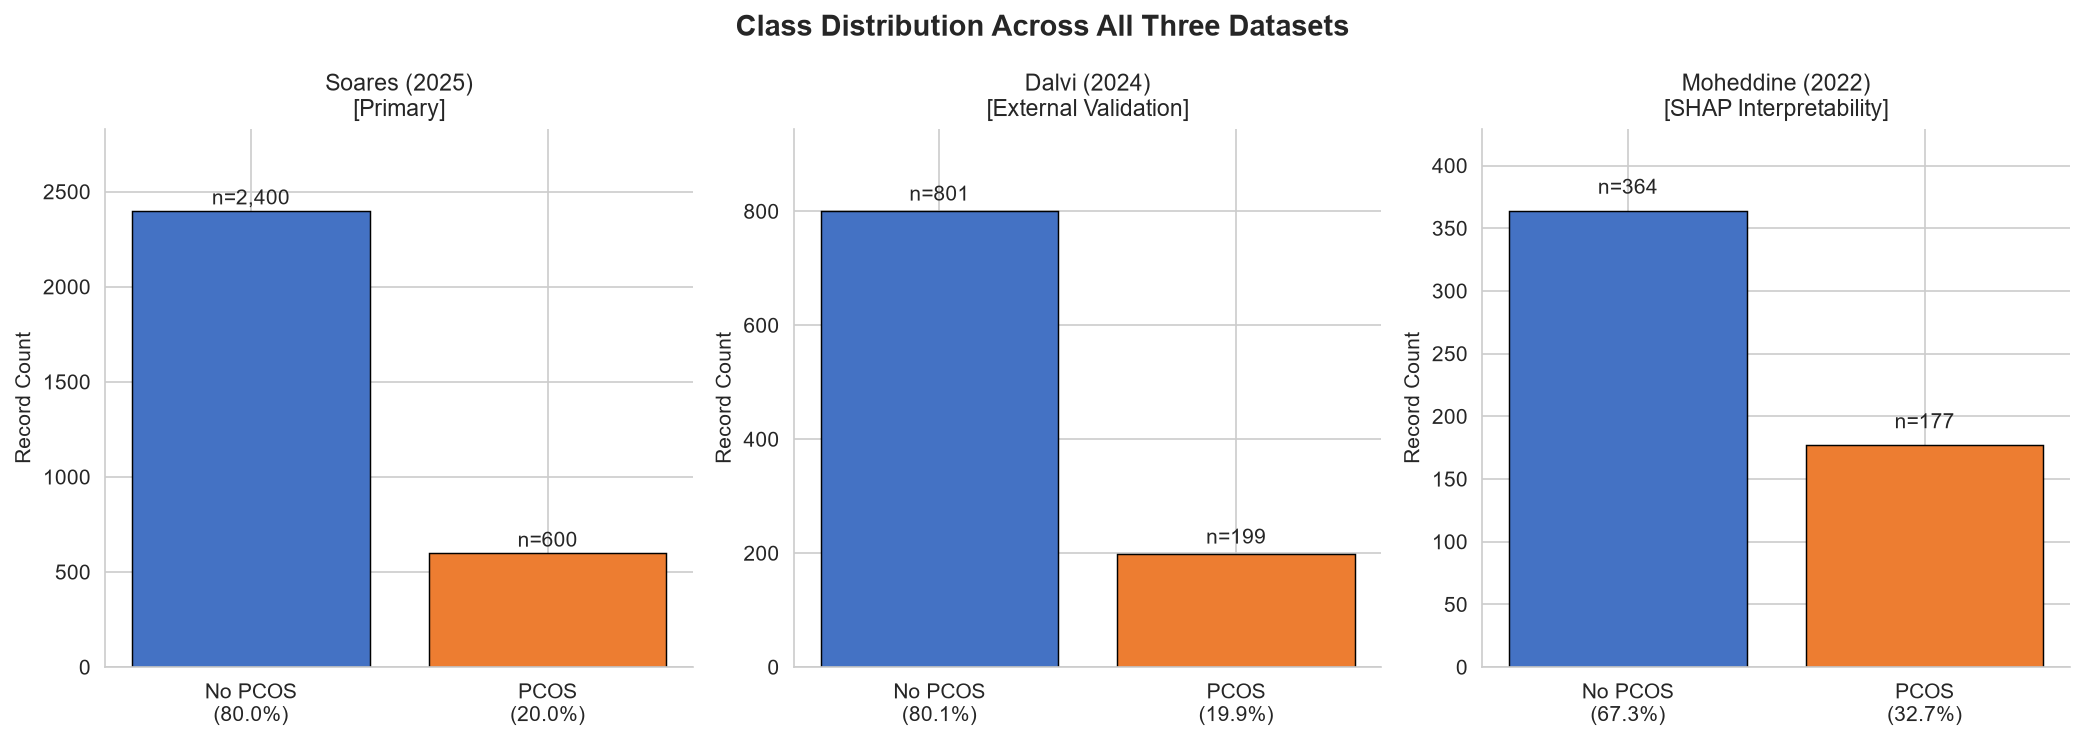

Figure saved: outputs/figures/fig1_class_distribution_all_datasets.png


In [14]:
# ============================================================
# SECTION 4: CLASS DISTRIBUTION VISUALISATION
# ============================================================

import os

# Ensure output directories exist
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

# ---- Dataset target variable mapping ----
datasets_info = {
    'Soares (2025)\n[Primary]': (soares, 'PCOS_Diagnosis'),
    'Dalvi (2024)\n[External Validation]': (dalvi, 'PCOS_Diagnosis'),
    'Moheddine (2022)\n[SHAP Interpretability]': (moheddine, 'PCOS (Y/N)')
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Class Distribution Across All Three Datasets', fontsize=14, fontweight='bold')

for ax, (label, (df, target)) in zip(axes, datasets_info.items()):
    counts = df[target].value_counts().sort_index()
    pcts   = df[target].value_counts(normalize=True).mul(100).round(1).sort_index()
    colors = ['#4472C4', '#ED7D31']  # Blue = 0 (No PCOS), Orange = 1 (Yes PCOS)
    bars = ax.bar(
        [f'No PCOS\n({pcts.get(0, 0)}%)', f'PCOS\n({pcts.get(1, 0)}%)'],
        [counts.get(0, 0), counts.get(1, 0)],
        color=colors, edgecolor='black', linewidth=0.7
    )
    # Add count labels on bars
    for bar, count in zip(bars, [counts.get(0, 0), counts.get(1, 0)]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                f'n={count:,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Record Count')
    ax.set_ylim(0, max(counts) * 1.18)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/fig1_class_distribution_all_datasets.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/figures/fig1_class_distribution_all_datasets.png")

**Figure 1: Class Distribution Across All Three Datasets - Observations**

Figure 1 shows the distribution of PCOS-positive and PCOS-negative records across
all three datasets used in this study.

The Soares and Dalvi datasets show near-identical distributions, with approximately
80% of records in the negative class in both cases. This consistency supports the
use of Dalvi as a genuine external validation set, since a model trained on Soares
will be evaluated on a dataset with a comparable base rate. If the two datasets had
markedly different class distributions, any difference in performance between the
test set and external validation results would be difficult to interpret, as it could
reflect distributional shift rather than true generalisation.

The Moheddine dataset shows a higher PCOS prevalence (32.7%) relative to the other
two datasets. This is consistent with the clinical origin of the dataset, where
patients presenting for gynaecological assessment are more likely to have a PCOS
diagnosis than a general population sample. This difference means that SHAP values
generated from models applied to Moheddine should be interpreted within the context
of a higher-prevalence clinical sample, and should not be directly compared to
model behaviour on the Soares or Dalvi datasets (Teede et al., 2018).

## Section 5: Descriptive Statistics

Summary statistics for all numeric features in each dataset are produced below. 
These provide the basis for the dataset description in the Methodology section of 
the research report and assist in identifying potential outliers before preprocessing.

In [9]:
# ============================================================
# SECTION 5: DESCRIPTIVE STATISTICS
# ============================================================

print("=== SOARES — Descriptive Statistics ===")
soares_desc = soares.describe().round(3)
print(soares_desc.to_string())
soares_desc.to_csv('../outputs/tables/soares_descriptive_stats.csv')

print("\n=== DALVI — Descriptive Statistics ===")
dalvi_desc = dalvi.describe().round(3)
print(dalvi_desc.to_string())
dalvi_desc.to_csv('../outputs/tables/dalvi_descriptive_stats.csv')

print("\n=== MOHEDDINE — Descriptive Statistics (numeric columns only) ===")
moheddine_desc = moheddine.describe().round(3)
print(moheddine_desc.to_string())
moheddine_desc.to_csv('../outputs/tables/moheddine_descriptive_stats.csv')

print("\nAll descriptive statistics saved to outputs/tables/")

=== SOARES — Descriptive Statistics ===
            Age       BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  Antral_Follicle_Count  PCOS_Diagnosis
count  3000.000  3000.000                3000.000                   3000.000               3000.000          3000.0
mean     30.053    23.646                   0.289                     57.228                 10.732             0.2
std       7.550     4.510                   0.454                     18.171                  8.471             0.4
min      18.000     8.500                   0.000                     20.500                  3.000             0.0
25%      24.000    20.800                   0.000                     45.200                  5.000             0.0
50%      30.000    23.400                   0.000                     53.200                  8.000             0.0
75%      36.000    26.300                   1.000                     64.100                 11.000             0.0
max      44.000    44.700       

## Section 6: Schema Alignment Check - Soares vs Dalvi

Because the Dalvi dataset is used for external validation with the scaler fitted on 
Soares training data, the two datasets must share identical feature names and 
compatible data types. This check confirms alignment before the preprocessing phase.

In [10]:
# ============================================================
# SECTION 6: SCHEMA ALIGNMENT — SOARES vs DALVI
# ============================================================

soares_cols = set(soares.columns)
dalvi_cols  = set(dalvi.columns)

# Columns in Soares but not Dalvi
only_soares = soares_cols - dalvi_cols
# Columns in Dalvi but not Soares
only_dalvi  = dalvi_cols - soares_cols
# Shared columns
shared      = soares_cols & dalvi_cols

print(f"Shared columns ({len(shared)}): {sorted(shared)}")
print(f"Only in Soares ({len(only_soares)}): {only_soares if only_soares else 'None'}")
print(f"Only in Dalvi  ({len(only_dalvi)}): {only_dalvi if only_dalvi else 'None'}")

if not only_soares and not only_dalvi:
    print("\n Schema alignment confirmed: Soares and Dalvi share identical column structures.")
    print("  External validation can proceed without feature engineering.")
else:
    print("\n WARNING: Schema mismatch detected. Investigate before proceeding.")

Shared columns (6): ['Age', 'Antral_Follicle_Count', 'BMI', 'Menstrual_Irregularity', 'PCOS_Diagnosis', 'Testosterone_Level(ng/dL)']
Only in Soares (0): None
Only in Dalvi  (0): None

 Schema alignment confirmed: Soares and Dalvi share identical column structures.
  External validation can proceed without feature engineering.


**Schema Alignment - Observations**

The schema check confirmed that Soares and Dalvi share all six columns with
identical names: Age, BMI, Menstrual Irregularity, Testosterone Level (ng/dL),
Antral Follicle Count, and PCOS Diagnosis. No columns are exclusive to either
dataset.

This alignment is necessary because the MinMaxScaler will be fitted on the Soares
training set and then applied to Dalvi without refitting. If column names or order
differed between the two datasets, the scaler would either raise an error or, more
dangerously, scale the wrong features silently. Confirming alignment here prevents
that class of data leakage from occurring downstream in the pipeline (Japkowicz
and Shah, 2011).

## Section 7: Day 1 Validation Summary

This cell produces a consolidated summary of all validation findings. Any issues 
flagged here must be resolved before proceeding to the EDA and preprocessing stages 
(Day 2 onwards). This summary will be referenced in the Methodology section of the 
research report when documenting the data preparation process.

In [11]:
# ============================================================
# SECTION 7: VALIDATION SUMMARY TABLE
# ============================================================

summary_data = {
    'Dataset': ['Soares (2025)', 'Dalvi (2024)', 'Moheddine (2022)'],
    'Role': ['Primary training/test', 'External validation', 'SHAP interpretability'],
    'Rows': [soares.shape[0], dalvi.shape[0], moheddine.shape[0]],
    'Columns': [soares.shape[1], dalvi.shape[1], moheddine.shape[1]],
    'Missing Values': [
        soares.isnull().sum().sum(),
        dalvi.isnull().sum().sum(),
        moheddine.isnull().sum().sum()
    ],
    'Duplicate Rows': [soares_dups, dalvi_dups, moheddine_dups],
    'Target Variable': ['PCOS_Diagnosis', 'PCOS_Diagnosis', 'PCOS (Y/N)'],
    'Class 0 (No PCOS) %': [
        round(soares['PCOS_Diagnosis'].value_counts(normalize=True).get(0, 0) * 100, 1),
        round(dalvi['PCOS_Diagnosis'].value_counts(normalize=True).get(0, 0) * 100, 1),
        round(moheddine['PCOS (Y/N)'].value_counts(normalize=True).get(0, 0) * 100, 1)
    ],
    'Class 1 (PCOS) %': [
        round(soares['PCOS_Diagnosis'].value_counts(normalize=True).get(1, 0) * 100, 1),
        round(dalvi['PCOS_Diagnosis'].value_counts(normalize=True).get(1, 0) * 100, 1),
        round(moheddine['PCOS (Y/N)'].value_counts(normalize=True).get(1, 0) * 100, 1)
    ],
    'Object Columns': [
        len(soares.select_dtypes(include='object').columns),
        len(dalvi.select_dtypes(include='object').columns),
        len(moheddine.select_dtypes(include='object').columns)
    ]
}

summary_df = pd.DataFrame(summary_data).set_index('Dataset')
print("=== DAY 1 VALIDATION SUMMARY ===\n")
print(summary_df.T.to_string())

# Save to CSV for the report
summary_df.to_csv('../outputs/tables/day1_validation_summary.csv')
print("\nValidation summary saved to outputs/tables/day1_validation_summary.csv")

# Final status check
issues = []
for ds_name, missing_df, dups in [
    ('Soares', soares_missing, soares_dups),
    ('Dalvi', dalvi_missing, dalvi_dups),
    ('Moheddine', moheddine_missing, moheddine_dups)
]:
    if not missing_df.empty:
        issues.append(f"  - {ds_name}: {missing_df['Missing Count'].sum()} missing values detected.")
    if dups > 0:
        issues.append(f"  - {ds_name}: {dups} duplicate rows detected.")

if issues:
    print("\n ISSUES REQUIRING RESOLUTION BEFORE PROCEEDING:")
    for issue in issues:
        print(issue)
    print("\n  Address these in Day 2 before EDA begins.")
else:
    print("\n All datasets passed validation. No blocking issues detected.")
    print("  Proceed to EDA on Day 2.")

=== DAY 1 VALIDATION SUMMARY ===

Dataset                      Soares (2025)         Dalvi (2024)       Moheddine (2022)
Role                 Primary training/test  External validation  SHAP interpretability
Rows                                  3000                 1000                    541
Columns                                  6                    6                     44
Missing Values                           0                    0                      2
Duplicate Rows                           0                    0                      0
Target Variable             PCOS_Diagnosis       PCOS_Diagnosis             PCOS (Y/N)
Class 0 (No PCOS) %                   80.0                 80.1                   67.3
Class 1 (PCOS) %                      20.0                 19.9                   32.7
Object Columns                           0                    0                      2

Validation summary saved to outputs/tables/day1_validation_summary.csv

 ISSUES REQUIRING RESOL

**Day 1 Validation Summary - Observations**

The validation summary confirms the following for Day 2 onwards:

Soares and Dalvi are clean and ready for preprocessing with no corrective steps
required. The Soares dataset will proceed directly to the stratified 80/20
train-test split, after which SMOTE will be applied to the training portion only.

The Moheddine dataset requires two preprocessing steps before it can be used for
SHAP analysis: conversion of the two object-typed columns to float64, and
single-value imputation for the two missing entries. These steps will be completed
at the start of the interpretability stage and documented as minor deviations from
the original preprocessing plan, which anticipated only integer encoding for nominal
variables in Moheddine.

No blocking issues were identified in Soares or Dalvi. The pipeline can proceed to
exploratory data analysis on Day 2.